In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip, struct
import time

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings('ignore')


# Ví dụ 1

In [2]:
#Read csv data file, change to your location
df = pd.read_csv("D:\\Workspace\\HUS\\Machine Learning\\5. PCA\\iris.csv")

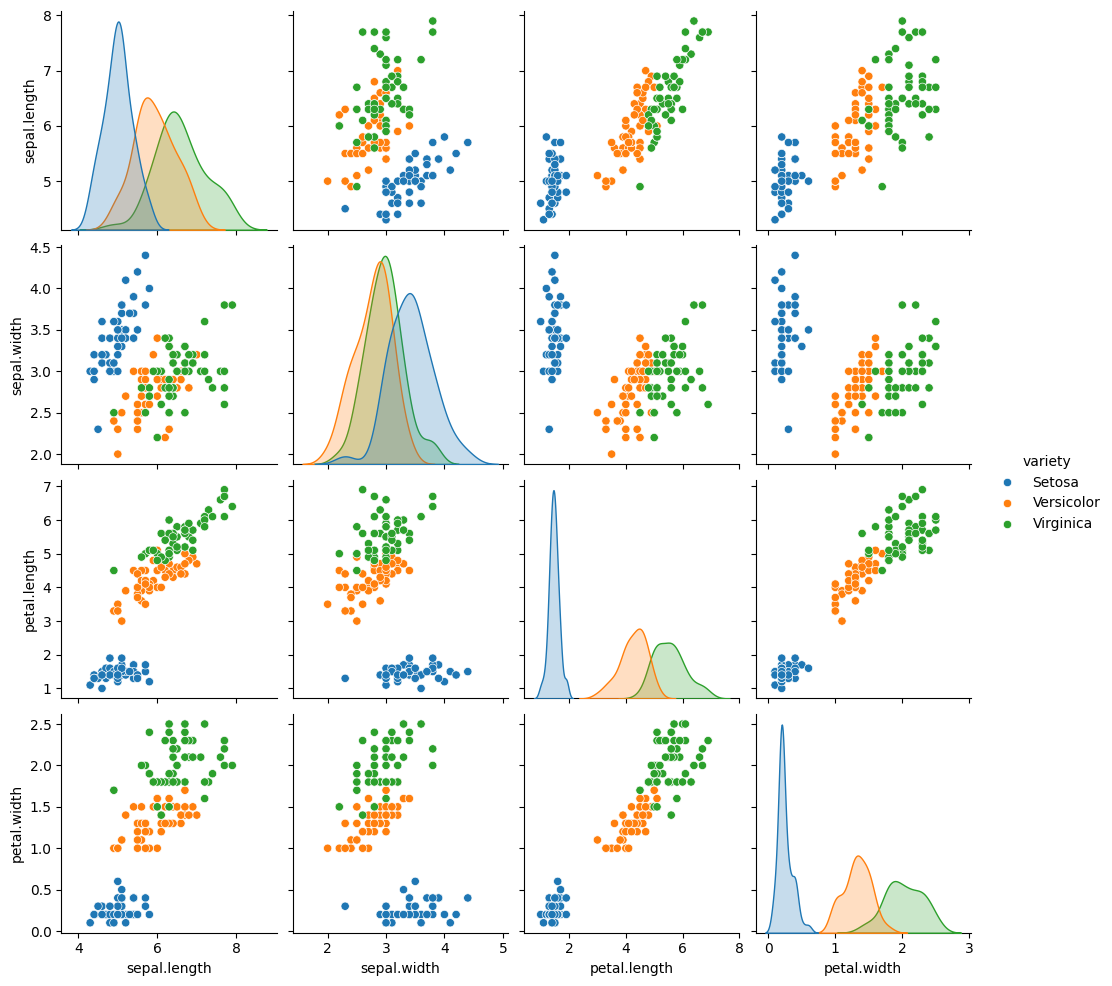

In [3]:
# show data information
df
df.describe()
sns.pairplot(df, hue = 'variety')

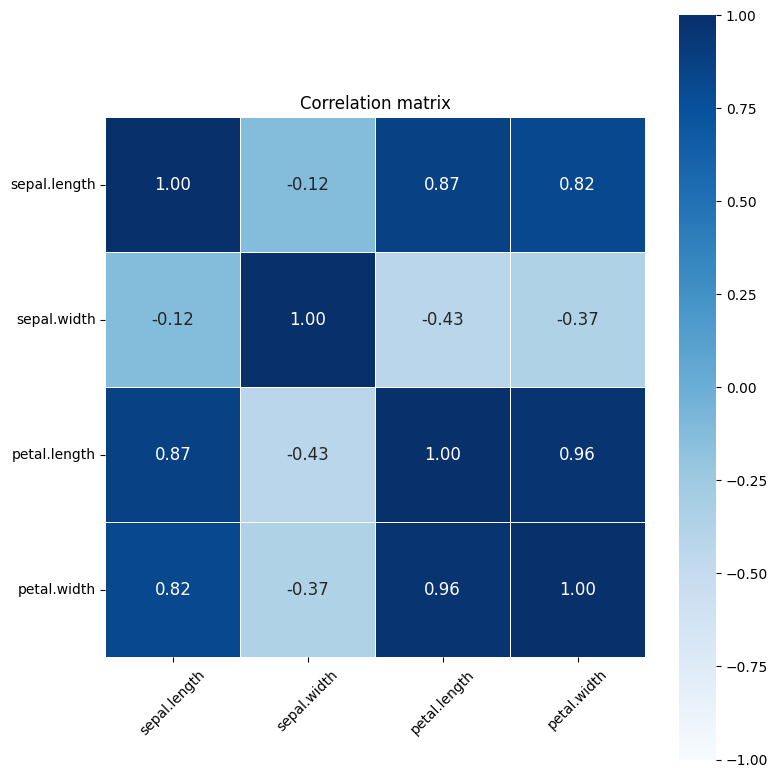

In [8]:
# We're seperating the species column
species = df["variety"].tolist()
X = df.drop("variety", axis=1)
# Standardize the data
X = (X - X.mean()) / X.std(ddof=0)
# Calculating the correlation matrix of the data
X_corr = (1 / 150) * X.T.dot(X)
plt.figure(figsize=(8,8))
cmap = sns.color_palette("Blues", as_cmap=True)
sns.heatmap(X_corr, cmap=cmap, vmax=1, vmin=-1, center=0, square=True, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size":12})
plt.title('Correlation matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:
# method1
u,s,v = np.linalg.svd(X_corr)
eig_values, eig_vectors = s, u
eig_values, eig_vectors
# method2
np.linalg.eig(X_corr)

EigResult(eigenvalues=array([2.91849782, 0.91403047, 0.14675688, 0.02071484]), eigenvectors=array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
       [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
       [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
       [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]]))

Text(0.5, 0, 'Dimension')

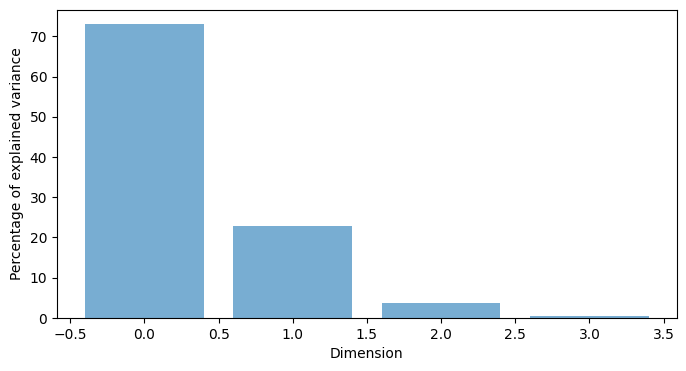

In [10]:
# plotting the variance explained by each PC
explained_variance=(eig_values / np.sum(eig_values))*100
plt.figure(figsize=(8,4))
plt.bar(range(4), explained_variance, alpha=0.6)
plt.ylabel('Percentage of explained variance')
plt.xlabel('Dimension')

In [11]:
# calculating our new axis
pc1 = X.dot(eig_vectors[:,0])
pc2 = X.dot(eig_vectors[:,1])

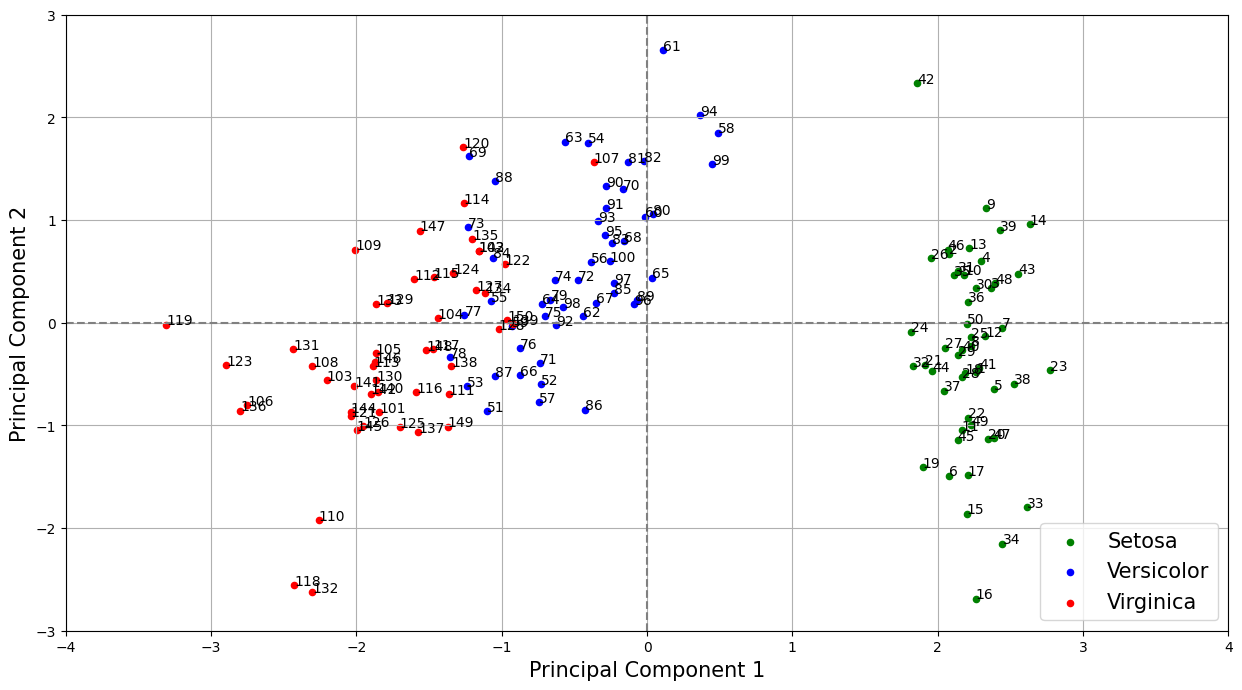

In [12]:
# plotting in 2D
def plot_scatter(pc1, pc2):
    fig, ax = plt.subplots(figsize=(15, 8))
    species_unique = list(set(species))
    species_colors = ["r","b","g"]
    for i, spec in enumerate(species):
        plt.scatter(pc1[i], pc2[i], label = spec, s = 20,c=species_colors[species_unique.index(spec)])
        ax.annotate(str(i+1), (pc1[i],pc2[i]))
    from collections import OrderedDict
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), prop={'size': 15}, loc=4)
    ax.set_xlabel('Principal Component 1', fontsize = 15)
    ax.set_ylabel('Principal Component 2', fontsize = 15)
    ax.axhline(y=0, color="grey", linestyle="--")
    ax.axvline(x=0, color="grey", linestyle="--")
    plt.grid()
    plt.axis([-4, 4, -3, 3])
    plt.show()
plot_scatter(pc1, pc2)

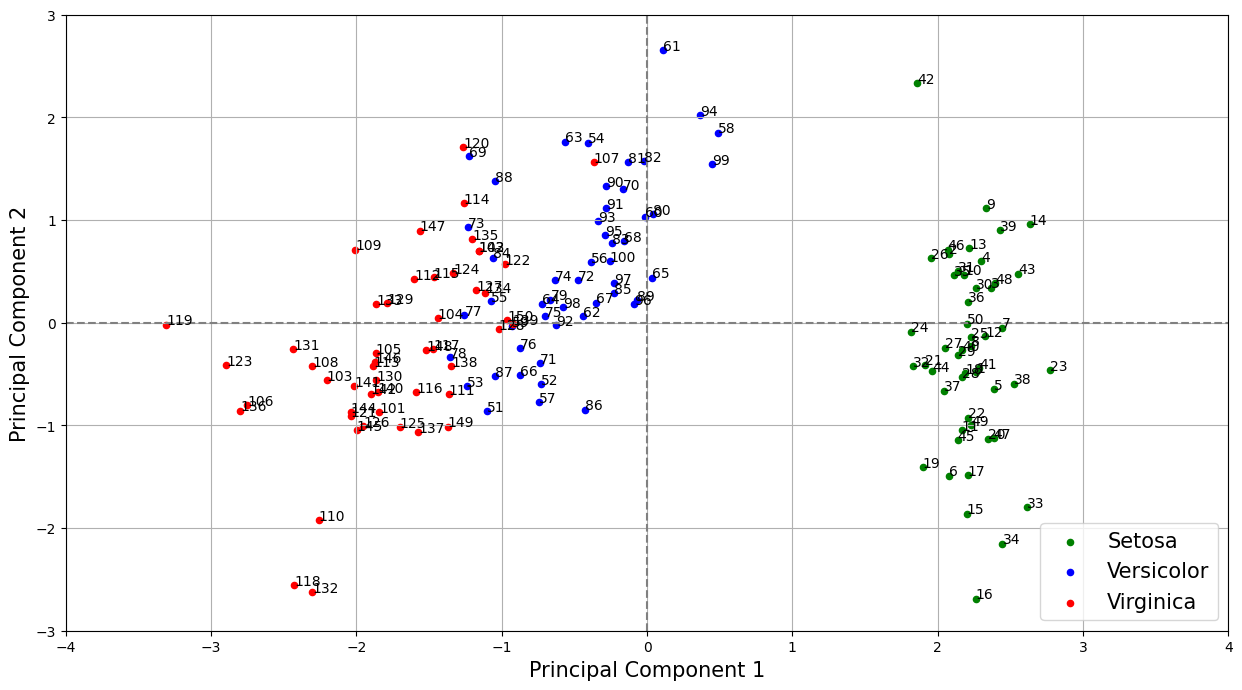

In [18]:
#Read csv data file, change to your location
df = pd.read_csv("D:\\Workspace\\HUS\\Machine Learning\\5. PCA\\iris.csv")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X = df.drop("variety", axis=1)
X = StandardScaler().fit_transform(X)
pca = PCA()
result = pca.fit_transform(X)
# Remember what we said about the sign of eigen vectors that might change ?
pc1 = - result[:,0]
pc2 = - result[:,1]
plot_scatter(pc1, pc2)

## Yêu cầu thực hành

### 1. Đưa tập dữ liệu về 2 chiều

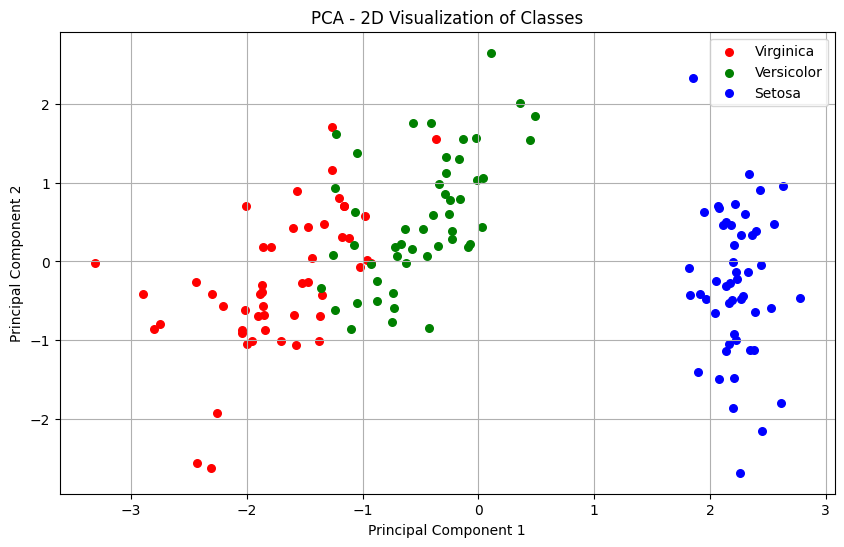

In [28]:
plt.figure(figsize=(10,6))
species_unique = list(set(species))
species_colors = ["r", "g", "b"]
for i, spec in enumerate(species_unique):
    idx = [j for j, s in enumerate(species) if s == spec]
    plt.scatter(pc1[idx], pc2[idx], label=spec, s=30, c=species_colors[i])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2D Visualization of Classes')
plt.legend()
plt.grid(True)
plt.show()

### 2. Chạy với Logistic Regression

#### a. Chạy với dữ liệu nguyên bản

Accuracy: 93.33%


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


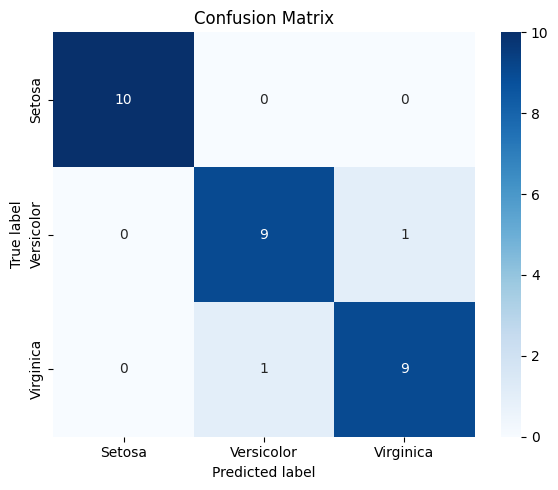

In [27]:
# Chuẩn hóa dữ liệu
X_raw = df.drop("variety", axis=1).values
species_arr = np.array(species)
X_std = StandardScaler().fit_transform(X_raw)

test_size = 0.2
train_idx, test_idx = [], []
np.random.seed(42)
for label in np.unique(species_arr):
    idx = np.where(species_arr == label)[0]
    np.random.shuffle(idx)
    n_train = int((1 - test_size) * len(idx))
    train_idx.extend(idx[:n_train])
    test_idx.extend(idx[n_train:])
X_train, X_test = X_std[train_idx], X_std[test_idx]
y_train, y_test = species_arr[train_idx], species_arr[test_idx]

# Huấn luyện LogisticRegression
logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

# Đánh giá
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.2f}%')
classes = np.unique(species_arr)
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title(f'Confusion Matrix')
plt.tight_layout()
plt.show()

#### b. Chạy với dữ liệu đã giảm chiều

Độ chính xác (PCA 2D): 0.8667


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


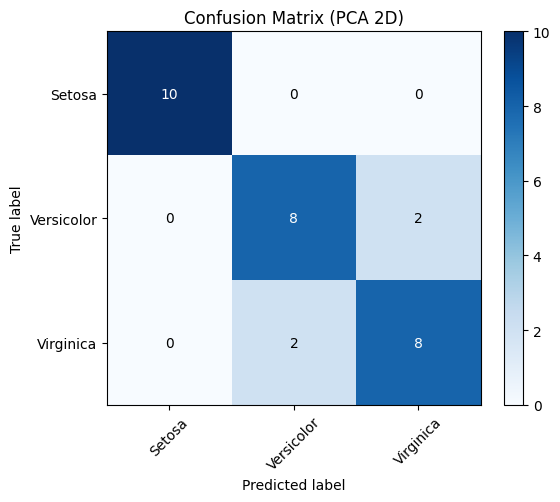

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.80      0.80      0.80        10
   Virginica       0.80      0.80      0.80        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



In [34]:
# Sử dụng pc1, pc2 đã tính ở trên làm đặc trưng đầu vào
X_pca2 = np.column_stack((pc1, pc2))
species_arr = np.array(species)

# Chia train/test 
train_idx, test_idx = [], []
for label in np.unique(species_arr):
    idx = np.where(species_arr == label)[0]
    n_train = int(0.8 * len(idx))
    np.random.seed(42)
    np.random.shuffle(idx)
    train_idx.extend(idx[:n_train])
    test_idx.extend(idx[n_train:])
X_train, X_test = X_pca2[train_idx], X_pca2[test_idx]
y_train, y_test = species_arr[train_idx], species_arr[test_idx]

# Huấn luyện LogisticRegression
logreg_pca = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
logreg_pca.fit(X_train, y_train)
y_pred = logreg_pca.predict(X_test)

# Đánh giá
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=np.unique(species_arr))
classes = np.unique(species_arr)

print(f"Độ chính xác (PCA 2D): {acc:.4f}")

plt.figure(figsize=(6,5))
cmap = plt.cm.Blues
plt.imshow(cm, interpolation='nearest', cmap=cmap)
plt.title('Confusion Matrix (PCA 2D)')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred))

##### 1. Quy trình 1: Chia dữ liệu thành Train – Test, sau đó thực hiện giảm chiều một cách phù hợp và thực hiện bài toán phân loại. Lưu lại các kết quả.

--- Quy trình 1: Chia train-test rồi giảm chiều ---
Độ chính xác: 0.8667
Ma trận nhầm lẫn:


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


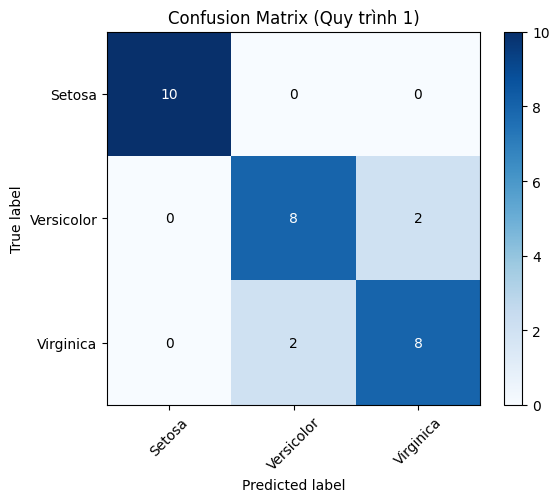

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.80      0.80      0.80        10
   Virginica       0.80      0.80      0.80        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



In [37]:
species_arr = np.array(species)
X_raw = df.drop("variety", axis=1).values
X_std = StandardScaler().fit_transform(X_raw)

# 1. Chia dữ liệu thành Train – Test, sau đó giảm chiều trên tập train và test riêng biệt
train_idx, test_idx = [], []
for label in np.unique(species_arr):
    idx = np.where(species_arr == label)[0]
    n_train = int(0.8 * len(idx))
    np.random.seed(42)
    np.random.shuffle(idx)
    train_idx.extend(idx[:n_train])
    test_idx.extend(idx[n_train:])
X_train, X_test = X_std[train_idx], X_std[test_idx]
y_train, y_test = species_arr[train_idx], species_arr[test_idx]

# Giảm chiều trên từng tập riêng biệt (fit PCA trên train, transform cả train và test)
pca1 = PCA(n_components=2)
X_train_pca1 = pca1.fit_transform(X_train)
X_test_pca1 = pca1.transform(X_test)
logreg1 = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
logreg1.fit(X_train_pca1, y_train)
y_pred1 = logreg1.predict(X_test_pca1)
acc1 = accuracy_score(y_test, y_pred1)
cm1 = confusion_matrix(y_test, y_pred1, labels=np.unique(species_arr))
print('--- Quy trình 1: Chia train-test rồi giảm chiều ---')
print(f"Độ chính xác: {acc1:.4f}")
print("Ma trận nhầm lẫn:")
classes = np.unique(species_arr)
plt.figure(figsize=(6,5))
plt.imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Quy trình 1)')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm1.max() / 2.
for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        plt.text(j, i, format(cm1[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm1[i, j] > thresh else 'black')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred1))

##### 2. Giảm chiều trên toàn bộ dữ liệu, sau đó chia train-test

In [36]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_std)
X_train2, X_test2 = X_pca2[train_idx], X_pca2[test_idx]
logreg2 = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
logreg2.fit(X_train2, y_train)
y_pred2 = logreg2.predict(X_test2)
acc2 = accuracy_score(y_test, y_pred2)
cm2 = confusion_matrix(y_test, y_pred2, labels=np.unique(species_arr))
print('--- Quy trình 2: Giảm chiều toàn bộ rồi chia train-test ---')
print(f"Độ chính xác: {acc2:.4f}")
print("Ma trận nhầm lẫn:")
print(cm2)
print(classification_report(y_test, y_pred2))

--- Quy trình 2: Giảm chiều toàn bộ rồi chia train-test ---
Độ chính xác: 0.8667
Ma trận nhầm lẫn:
[[10  0  0]
 [ 0  8  2]
 [ 0  2  8]]
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.80      0.80      0.80        10
   Virginica       0.80      0.80      0.80        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### So sánh và giải thích kết quả các quy trình giảm chiều với Logistic Regression

**So sánh hai quy trình giảm chiều:**
- **i.Chia train-test rồi mới giảm chiều (fit PCA trên train, transform test):**
  - Đảm bảo rằng các thành phần chính (principal components) chỉ phản ánh cấu trúc của tập train, giống như khi triển khai thực tế.
  - Kết quả phân loại thường phản ánh đúng năng lực mô hình trên dữ liệu chưa từng thấy.

- **ii. Giảm chiều toàn bộ rồi mới chia train-test:**
  - PCA được fit trên toàn bộ dữ liệu, bao gồm cả test, dẫn đến rò rỉ thông tin (data leakage).
  - Các thành phần chính có thể phản ánh cả cấu trúc của test, khiến kết quả phân loại trên test thường cao hơn thực tế.
  - Quy trình này không nên dùng khi đánh giá mô hình thực tế.

**So sánh với dữ liệu nguyên bản:**
- Dữ liệu nguyên bản (đầy đủ chiều) thường cho kết quả phân loại tốt nhất vì không mất mát thông tin.
- Dữ liệu giảm chiều (PCA 2D) giúp trực quan hóa, giảm nhiễu, nhưng có thể làm giảm độ chính xác do mất thông tin.
- Nếu độ chính xác khi giảm chiều không giảm nhiều so với dữ liệu nguyên bản, có thể cân nhắc dùng PCA để đơn giản hóa mô hình, tăng tốc độ huấn luyện và trực quan hóa.

**Kết luận:**
- Khi giảm chiều để phục vụ phân loại/hồi quy, luôn phải chia train-test trước rồi mới fit PCA trên train và transform test.
- Không nên fit PCA trên toàn bộ dữ liệu trước khi chia train-test để tránh rò rỉ thông tin.
- Cần so sánh kết quả với dữ liệu nguyên bản để đánh giá mức độ mất mát thông tin khi giảm chiều.

# Ví dụ 2: (Bài tập thực hành 1)

In [5]:
df = pd.read_csv("D:\\Workspace\\HUS\\Machine Learning\\5. PCA\\pd_speech_features.csv")
df.head()
df['class'].value_counts()

class
1    564
0    192
Name: count, dtype: int64

## 1. Sử dụng đoạn code chọn số chiều chính trong ví dụ 2, đưa tập dữ liệu đã đọc về còn 2 chiều, sau đó hiển thị lên màn hình để xem quan hệ giữa các lớp dữ liệu.

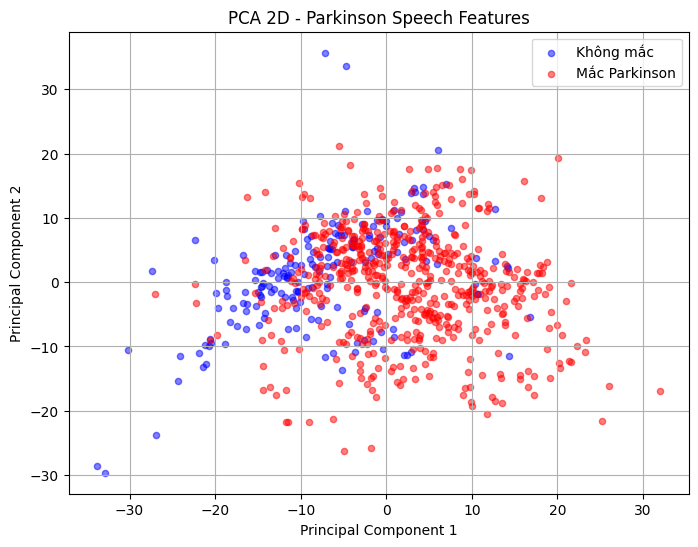

In [6]:
X_pd = df.drop('class', axis=1).values
y_pd = df['class'].values
X_pd_std = StandardScaler().fit_transform(X_pd)
# Giảm chiều với PCA
pca_pd = PCA(n_components=2)
X_pd_pca = pca_pd.fit_transform(X_pd_std)

# Trực quan hóa
plt.figure(figsize=(8,6))
for label, color, name in zip([0,1], ['blue', 'red'], ['Không mắc', 'Mắc Parkinson']):
    idx = (y_pd == label)
    plt.scatter(X_pd_pca[idx,0], X_pd_pca[idx,1], c=color, label=name, alpha=0.5, s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA 2D - Parkinson Speech Features')
plt.legend()
plt.grid(True)
plt.show()

## 2. Giảm số chiều xuống còn 200 ứng với thành phần chính của dữ liệu bằng PCA nhằm phục vụ cho việc phân loại dữ liệu (theo class), với phần dữ liệu Train gồm 500 bản ghi và dữ liệu kiểm tra là phần còn lại. Dùng các công cụ đo độ chính xác để kiểm tra đánh giá mô hình.

Total records: 756, features: 754
Train shape: (500, 754), Test shape: (256, 754)
Explained variance by 200 components: 97.94%
Accuracy (PCA-200): 0.8242

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        65
           1       0.87      0.90      0.88       191

    accuracy                           0.82       256
   macro avg       0.77      0.75      0.76       256
weighted avg       0.82      0.82      0.82       256

ROC AUC could not be computed: name 'roc_auc_score' is not defined
Explained variance by 200 components: 97.94%
Accuracy (PCA-200): 0.8242

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        65
           1       0.87      0.90      0.88       191

    accuracy                           0.82       256
   macro avg       0.77      0.75      0.76       256
weighted avg       0.82      0.82      0.82       256

ROC A

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


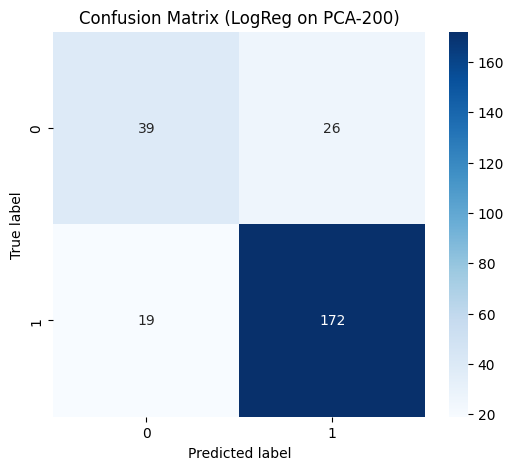

PCA components shape: (200, 754)


In [7]:
# Prepare X, y
X = df.drop('class', axis=1).values
y = df['class'].values
n_samples = X.shape[0]
print(f"Total records: {n_samples}, features: {X.shape[1]}")

# Ensure we have at least 500 samples
if n_samples < 500:
    raise ValueError(f"Dataset has only {n_samples} records, need at least 500 for the requested train size.")

# Split: train_size = 500, stratify by class to keep class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=500, stratify=y, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Standardize based on TRAIN only
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

# PCA: reduce to 200 components, fit on train only
n_components = 200
if n_components > X_train_std.shape[1]:
    raise ValueError(f"Requested n_components={n_components} > n_features={X_train_std.shape[1]}")

pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# How much variance is captured by the 200 components
explained = np.sum(pca.explained_variance_ratio_)
print(f"Explained variance by {n_components} components: {explained*100:.2f}%")

# Train Logistic Regression on PCA features
logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
logreg.fit(X_train_pca, y_train)

# Predict and evaluate
y_pred = logreg.predict(X_test_pca)
y_proba = logreg.predict_proba(X_test_pca)[:, 1] if hasattr(logreg, 'predict_proba') else None
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))

print(f"Accuracy (PCA-{n_components}): {acc:.4f}")
print('\nClassification report:')
print(classification_report(y_test, y_pred))
if y_proba is not None and len(np.unique(y_test)) == 2:
    try:
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC AUC: {auc:.4f}")
    except Exception as e:
        print('ROC AUC could not be computed:', e)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title(f'Confusion Matrix (LogReg on PCA-{n_components})')
plt.show()

# Optionally show a small sample of PCA components for inspection
print('PCA components shape:', pca.components_.shape)

## 3. Lấy dữ liệu gốc và chia thành tập train:test như tỷ lệ trong ý 2), sau đó giảm chiều về 200 chiều cho cả hai tập bằng PCA và thực hiện lại bài toán phân lớp dữ liệu. So sánh độ chính xác với ý 2).

Dataset: 756 samples, 754 features
[A] Explained variance by 200 components (fit on train): 97.94%
[A] Accuracy (PCA on train): 0.8242
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        65
           1       0.87      0.90      0.88       191

    accuracy                           0.82       256
   macro avg       0.77      0.75      0.76       256
weighted avg       0.82      0.82      0.82       256

[A] Explained variance by 200 components (fit on train): 97.94%
[A] Accuracy (PCA on train): 0.8242
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        65
           1       0.87      0.90      0.88       191

    accuracy                           0.82       256
   macro avg       0.77      0.75      0.76       256
weighted avg       0.82      0.82      0.82       256



C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


[B] Explained variance by 200 components (fit on full): 96.84%
[B] Accuracy (PCA on full): 0.8125
              precision    recall  f1-score   support

           0       0.65      0.55      0.60        65
           1       0.86      0.90      0.88       191

    accuracy                           0.81       256
   macro avg       0.76      0.73      0.74       256
weighted avg       0.80      0.81      0.81       256


Summary:
Accuracy A (fit on train): 0.8242
Accuracy B (fit on full):  0.8125


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


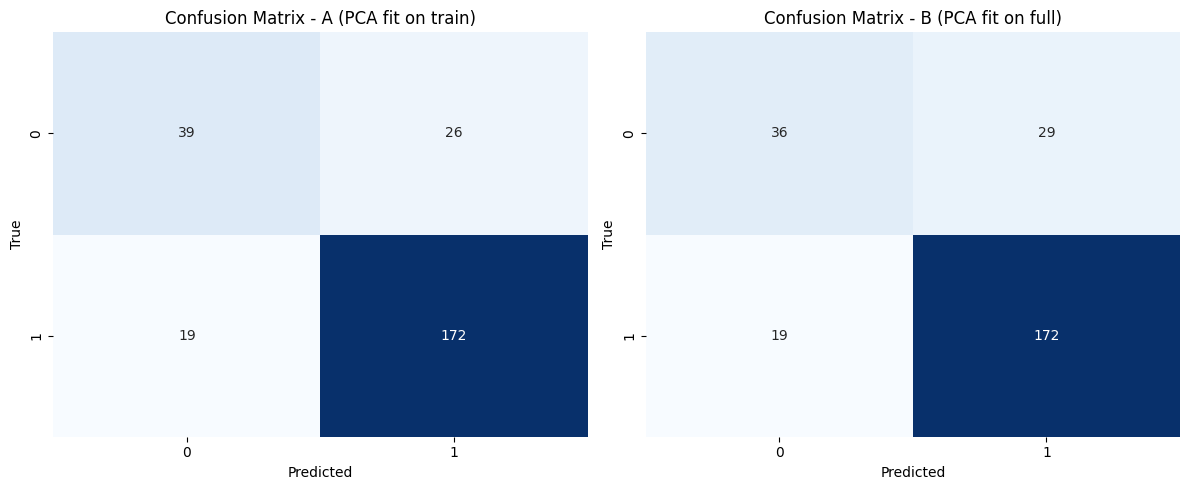


Notes:
- Method A avoids data leakage (recommended for real evaluation).
- Method B may overestimate performance due to PCA fitted on full data including test.


In [9]:
n_samples, n_features = X.shape
print(f"Dataset: {n_samples} samples, {n_features} features")

train_size = 500

# Create stratified split indices (same split used for both methods for fair comparison)
X_train_idx, X_test_idx, y_train_idx, y_test_idx = train_test_split(np.arange(n_samples), y, train_size=train_size, stratify=y, random_state=42)

# Method A: Fit scaler+PCA on TRAIN only, then transform TEST
X_train = X[X_train_idx]
X_test = X[X_test_idx]

scaler_A = StandardScaler().fit(X_train)
X_train_std_A = scaler_A.transform(X_train)
X_test_std_A = scaler_A.transform(X_test)

n_components = 200
if n_components > n_features:
    raise ValueError(f"n_components ({n_components}) > n_features ({n_features})")

pca_A = PCA(n_components=n_components, random_state=42)
X_train_pca_A = pca_A.fit_transform(X_train_std_A)
X_test_pca_A = pca_A.transform(X_test_std_A)

explained_A = np.sum(pca_A.explained_variance_ratio_)
print(f"[A] Explained variance by {n_components} components (fit on train): {explained_A*100:.2f}%")

clf_A = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_A.fit(X_train_pca_A, y[X_train_idx])
y_pred_A = clf_A.predict(X_test_pca_A)
y_proba_A = clf_A.predict_proba(X_test_pca_A)[:,1] if hasattr(clf_A,'predict_proba') else None
acc_A = accuracy_score(y[X_test_idx], y_pred_A)
cm_A = confusion_matrix(y[X_test_idx], y_pred_A)
print(f"[A] Accuracy (PCA on train): {acc_A:.4f}")
print(classification_report(y[X_test_idx], y_pred_A))
if y_proba_A is not None and len(np.unique(y))==2:
    try:
        print(f"[A] ROC AUC: {roc_auc_score(y[X_test_idx], y_proba_A):.4f}")
    except Exception:
        pass

# Method B: Fit scaler+PCA on FULL data, transform FULL, then split into train/test (same train indices)
scaler_B = StandardScaler().fit(X)
X_std_B = scaler_B.transform(X)

pca_B = PCA(n_components=n_components, random_state=42)
X_pca_B = pca_B.fit_transform(X_std_B)
explained_B = np.sum(pca_B.explained_variance_ratio_)
print(f"[B] Explained variance by {n_components} components (fit on full): {explained_B*100:.2f}%")

X_train_pca_B = X_pca_B[X_train_idx]
X_test_pca_B = X_pca_B[X_test_idx]

clf_B = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_B.fit(X_train_pca_B, y[X_train_idx])
y_pred_B = clf_B.predict(X_test_pca_B)
y_proba_B = clf_B.predict_proba(X_test_pca_B)[:,1] if hasattr(clf_B,'predict_proba') else None
acc_B = accuracy_score(y[X_test_idx], y_pred_B)
cm_B = confusion_matrix(y[X_test_idx], y_pred_B)
print(f"[B] Accuracy (PCA on full): {acc_B:.4f}")
print(classification_report(y[X_test_idx], y_pred_B))
if y_proba_B is not None and len(np.unique(y))==2:
    try:
        print(f"[B] ROC AUC: {roc_auc_score(y[X_test_idx], y_proba_B):.4f}")
    except Exception:
        pass

# Compare
print('\nSummary:')
print(f"Accuracy A (fit on train): {acc_A:.4f}")
print(f"Accuracy B (fit on full):  {acc_B:.4f}")

# Plot confusion matrices side by side
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - A (PCA fit on train)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_B, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - B (PCA fit on full)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

# Notes
print('\nNotes:')
print('- Method A avoids data leakage (recommended for real evaluation).')
print('- Method B may overestimate performance due to PCA fitted on full data including test.')

## 4. Thực hiện các yêu cầu sau: Hãy sử dụng phương phap PCA để đưa dữ liệu về số chiều nhỏ nhất sao cho lượng thông tin được giữ lại ít nhất đạt 80%.
i. Cho biết dữ liệu mới còn bao nhiêu chiều.

ii. Thực hiện lại bài toán phân loại với tỷ lệ như trên, ứng với dữ liệu mới và so sánh độ chính
xác.

Dataset: 756 samples, 754 features
Minimal n_components to retain >= 80% variance: 52
Explained variance by first 52 components: 80.25%

--- Result A (PCA fit on TRAIN, retain >=80%) ---
n_components: 52
Accuracy: 0.8398
              precision    recall  f1-score   support

           0       0.69      0.66      0.68        65
           1       0.89      0.90      0.89       191

    accuracy                           0.84       256
   macro avg       0.79      0.78      0.79       256
weighted avg       0.84      0.84      0.84       256



C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


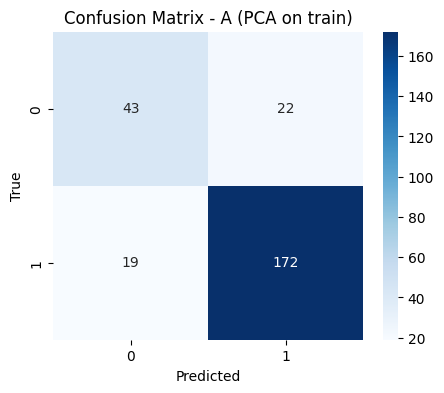

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(



--- Baseline (original standardized features) ---
Accuracy: 0.8320
              precision    recall  f1-score   support

           0       0.69      0.62      0.65        65
           1       0.87      0.91      0.89       191

    accuracy                           0.83       256
   macro avg       0.78      0.76      0.77       256
weighted avg       0.83      0.83      0.83       256



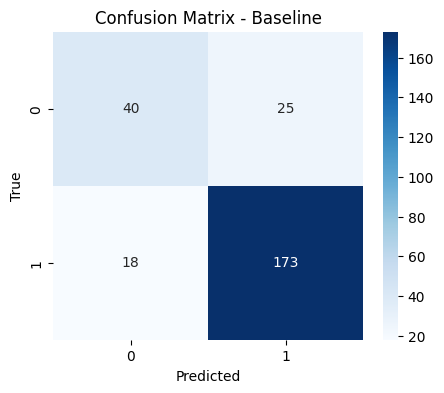


--- Demo (PCA fit on FULL then split) ---
Accuracy (PCA fit on full data): 0.8281

Summary:
Baseline accuracy (no PCA): 0.8320
PCA(52) accuracy (fit on train): 0.8398
PCA(52) accuracy (fit on full) [NOT recommended]: 0.8281

PCA results saved to variable `pca_results`.


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [13]:
n_samples, n_features = X.shape
print(f"Dataset: {n_samples} samples, {n_features} features")

train_size = 500
if n_samples < train_size:
    raise ValueError(f"Need at least {train_size} samples; dataset has {n_samples}.")

# Use a stratified split (same split for all comparisons)
indices = np.arange(n_samples)
train_idx, test_idx, _, _ = train_test_split(indices, y, train_size=train_size, stratify=y, random_state=42)

# Prepare train/test
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Standardize based on TRAIN only
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

# 1) Fit PCA on TRAIN with all components to compute cumulative explained variance
pca_full = PCA(n_components=min(n_features, X_train_std.shape[0]), random_state=42)
pca_full.fit(X_train_std)
explained_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

# Find minimal components >= 80%
threshold = 0.80
n_comp_80 = int(np.searchsorted(cum_explained, threshold) + 1)
print(f"Minimal n_components to retain >= {threshold*100:.0f}% variance: {n_comp_80}")
print(f"Explained variance by first {n_comp_80} components: {cum_explained[n_comp_80-1]*100:.2f}%")

# 2) Pipeline A: fit PCA(n_comp_80) on TRAIN, transform both sets, train LogisticRegression
pca_A = PCA(n_components=n_comp_80, random_state=42)
X_train_pca_A = pca_A.fit_transform(X_train_std)
X_test_pca_A = pca_A.transform(X_test_std)

clf_A = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_A.fit(X_train_pca_A, y_train)
y_pred_A = clf_A.predict(X_test_pca_A)
acc_A = accuracy_score(y_test, y_pred_A)
cm_A = confusion_matrix(y_test, y_pred_A)

print('\n--- Result A (PCA fit on TRAIN, retain >=80%) ---')
print(f"n_components: {n_comp_80}")
print(f"Accuracy: {acc_A:.4f}")
print(classification_report(y_test, y_pred_A))

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - A (PCA on train)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

# 3) Baseline: train LogisticRegression on original standardized features (no PCA)
clf_base = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_base.fit(X_train_std, y_train)
y_pred_base = clf_base.predict(X_test_std)
acc_base = accuracy_score(y_test, y_pred_base)
cm_base = confusion_matrix(y_test, y_pred_base)

print('\n--- Baseline (original standardized features) ---')
print(f"Accuracy: {acc_base:.4f}")
print(classification_report(y_test, y_pred_base))
plt.figure(figsize=(5,4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - Baseline')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

# 4) Optional check: PCA fit on FULL data then split (for demonstration only) --> not recommended for evaluation
scaler_full = StandardScaler().fit(X)
X_std_full = scaler_full.transform(X)
pca_full_fit = PCA(n_components=n_comp_80, random_state=42).fit(X_std_full)
X_pca_full = pca_full_fit.transform(X_std_full)
X_train_pca_full = X_pca_full[train_idx]
X_test_pca_full = X_pca_full[test_idx]
clf_full = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_full.fit(X_train_pca_full, y_train)
y_pred_full = clf_full.predict(X_test_pca_full)
acc_full = accuracy_score(y_test, y_pred_full)

print('\n--- Demo (PCA fit on FULL then split) ---')
print(f"Accuracy (PCA fit on full data): {acc_full:.4f}")

# Summary table print
print('\nSummary:')
print(f"Baseline accuracy (no PCA): {acc_base:.4f}")
print(f"PCA({n_comp_80}) accuracy (fit on train): {acc_A:.4f}")
print(f"PCA({n_comp_80}) accuracy (fit on full) [NOT recommended]: {acc_full:.4f}")

# Save results in variables for further use
pca_results = {
    'n_components_80': n_comp_80,
    'explained_80': float(cum_explained[n_comp_80-1]),
    'acc_baseline': float(acc_base),
    'acc_pca_train': float(acc_A),
    'acc_pca_full': float(acc_full)
}
print('\nPCA results saved to variable `pca_results`.')

## 5. Sử dụng dữ liệu ban đầu, chia thành các tập Train- Test với tỷ lệ 4:2, sau đó áp dụng phương pháp Naïve Bayes phù hợp và phương pháp Hồi quy Logistic để thực hiện bài toán phân loại (theo class). Tiếp theo lại thực nghiệm các mô hình nói trên với dữ liệu đã giảm chiều ở ý 4), cùng tỷ lệ chia như trên. Hãy đánh giá xem 2 mô hình này, mô hình nào có độ chính xác thay đổi nhiều hơn.

Dataset: 756 samples, 754 features
Train shape: (504, 754), Test shape: (252, 754)
Results on ORIGINAL standardized features:
GaussianNB accuracy: 0.7659
              precision    recall  f1-score   support

           0       0.54      0.59      0.56        64
           1       0.86      0.82      0.84       188

    accuracy                           0.77       252
   macro avg       0.70      0.71      0.70       252
weighted avg       0.77      0.77      0.77       252

LogisticRegression accuracy: 0.8373
              precision    recall  f1-score   support

           0       0.71      0.61      0.66        64
           1       0.87      0.91      0.89       188

    accuracy                           0.84       252
   macro avg       0.79      0.76      0.77       252
weighted avg       0.83      0.84      0.83       252



C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(



Minimal PCA components on TRAIN for >=80% variance: 52
Explained variance by first 52 components: 80.16%

Results on PCA-reduced features (retain >=80%):
GaussianNB accuracy (PCA): 0.7421
              precision    recall  f1-score   support

           0       0.48      0.19      0.27        64
           1       0.77      0.93      0.84       188

    accuracy                           0.74       252
   macro avg       0.63      0.56      0.56       252
weighted avg       0.70      0.74      0.70       252

LogisticRegression accuracy (PCA): 0.8333
              precision    recall  f1-score   support

           0       0.70      0.59      0.64        64
           1       0.87      0.91      0.89       188

    accuracy                           0.83       252
   macro avg       0.79      0.75      0.77       252
weighted avg       0.83      0.83      0.83       252



C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


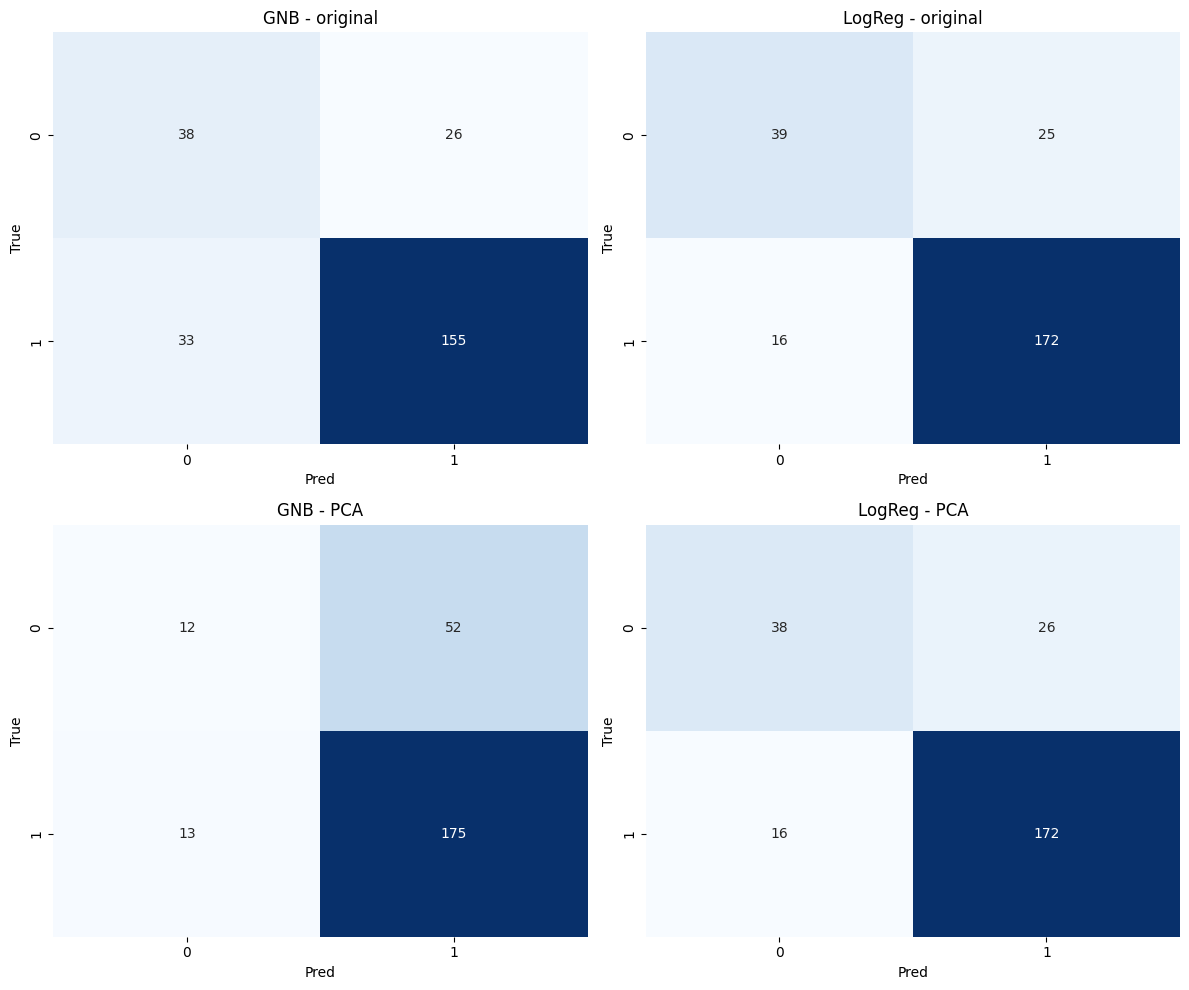


Accuracy changes (absolute):
GaussianNB change: 0.0238 (orig 0.7659 -> PCA 0.7421)
LogisticRegression change: 0.0040 (orig 0.8373 -> PCA 0.8333)

GaussianNB accuracy changed more after PCA reduction.

Comparison results saved to variable `comparison_results`.


In [16]:
n_samples, n_features = X.shape
print(f"Dataset: {n_samples} samples, {n_features} features")

# Split ratio 4:2 => train_size = 4/6 = 2/3
train_size = 4/6
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, stratify=y, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Standardize based on TRAIN only
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

# --- Models on original standardized features ---
# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_std, y_train)
y_pred_gnb = gnb.predict(X_test_std)
acc_gnb_orig = accuracy_score(y_test, y_pred_gnb)
cm_gnb_orig = confusion_matrix(y_test, y_pred_gnb)

# Logistic Regression
logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
logreg.fit(X_train_std, y_train)
y_pred_log_orig = logreg.predict(X_test_std)
acc_log_orig = accuracy_score(y_test, y_pred_log_orig)
cm_log_orig = confusion_matrix(y_test, y_pred_log_orig)

print('Results on ORIGINAL standardized features:')
print(f'GaussianNB accuracy: {acc_gnb_orig:.4f}')
print(classification_report(y_test, y_pred_gnb))
print(f'LogisticRegression accuracy: {acc_log_orig:.4f}')
print(classification_report(y_test, y_pred_log_orig))

# Plot confusion matrices
fig, axes = plt.subplots(2,2, figsize=(12,10))
sns.heatmap(cm_gnb_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], cbar=False)
axes[0,0].set_title('GNB - original')
axes[0,0].set_ylabel('True'); axes[0,0].set_xlabel('Pred')

sns.heatmap(cm_log_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0,1], cbar=False)
axes[0,1].set_title('LogReg - original')
axes[0,1].set_ylabel('True'); axes[0,1].set_xlabel('Pred')

# --- Determine minimal PCA components on TRAIN to retain >=80% variance ---
pca_full = PCA(n_components=min(X_train_std.shape[0], X_train_std.shape[1]), random_state=42)
pca_full.fit(X_train_std)
cum_explained = np.cumsum(pca_full.explained_variance_ratio_)
threshold = 0.80
n_comp_80 = int(np.searchsorted(cum_explained, threshold) + 1)
print(f"\nMinimal PCA components on TRAIN for >=80% variance: {n_comp_80}")
print(f"Explained variance by first {n_comp_80} components: {cum_explained[n_comp_80-1]*100:.2f}%")

# Fit PCA(n_comp_80) on TRAIN and transform both sets
pca = PCA(n_components=n_comp_80, random_state=42)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# --- Models on PCA-reduced features ---
# GaussianNB on PCA
gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)
y_pred_gnb_pca = gnb_pca.predict(X_test_pca)
acc_gnb_pca = accuracy_score(y_test, y_pred_gnb_pca)
cm_gnb_pca = confusion_matrix(y_test, y_pred_gnb_pca)

# LogisticRegression on PCA
log_pca = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_pca.fit(X_train_pca, y_train)
y_pred_log_pca = log_pca.predict(X_test_pca)
acc_log_pca = accuracy_score(y_test, y_pred_log_pca)
cm_log_pca = confusion_matrix(y_test, y_pred_log_pca)

print('\nResults on PCA-reduced features (retain >=80%):')
print(f'GaussianNB accuracy (PCA): {acc_gnb_pca:.4f}')
print(classification_report(y_test, y_pred_gnb_pca))
print(f'LogisticRegression accuracy (PCA): {acc_log_pca:.4f}')
print(classification_report(y_test, y_pred_log_pca))

sns.heatmap(cm_gnb_pca, annot=True, fmt='d', cmap='Blues', ax=axes[1,0], cbar=False)
axes[1,0].set_title('GNB - PCA')
axes[1,0].set_ylabel('True'); axes[1,0].set_xlabel('Pred')

sns.heatmap(cm_log_pca, annot=True, fmt='d', cmap='Blues', ax=axes[1,1], cbar=False)
axes[1,1].set_title('LogReg - PCA')
axes[1,1].set_ylabel('True'); axes[1,1].set_xlabel('Pred')

plt.tight_layout()
plt.show()

# Compute absolute accuracy changes
change_gnb = abs(acc_gnb_orig - acc_gnb_pca)
change_log = abs(acc_log_orig - acc_log_pca)

print('\nAccuracy changes (absolute):')
print(f'GaussianNB change: {change_gnb:.4f} (orig {acc_gnb_orig:.4f} -> PCA {acc_gnb_pca:.4f})')
print(f'LogisticRegression change: {change_log:.4f} (orig {acc_log_orig:.4f} -> PCA {acc_log_pca:.4f})')

if change_gnb > change_log:
    print('\nGaussianNB accuracy changed more after PCA reduction.')
elif change_log > change_gnb:
    print('\nLogisticRegression accuracy changed more after PCA reduction.')
else:
    print('\nBoth models changed by the same amount.')

# Save comparison results
comparison_results = {
    'acc_gnb_orig': float(acc_gnb_orig),
    'acc_log_orig': float(acc_log_orig),
    'acc_gnb_pca': float(acc_gnb_pca),
    'acc_log_pca': float(acc_log_pca),
    'change_gnb': float(change_gnb),
    'change_log': float(change_log),
    'n_comp_80': int(n_comp_80)
}
print('\nComparison results saved to variable `comparison_results`.')

# Ví dụ 3 (Bài tập thực hành 2)

In [17]:
file_path = r"D:\\Workspace\\HUS\\Machine Learning\\5. PCA\\vidu4_lin_reg.txt"
df_lin = pd.read_csv(file_path, delim_whitespace=True)
# Inspect
print('Loaded rows:', df_lin.shape[0])
print(df_lin.head())

Loaded rows: 100
   ID  TUOI  BMI   HA  GLUCOSE  CHOLESTEROL  BEDAYNTM
0   1    56   21  160     14.0         6.00      1.95
1   2    76   18  150     12.0         4.97      1.33
2   3    63   16  160      4.4         6.39      0.83
3   4    78   20  100      4.0         7.00      2.00
4   5    87   20  110      4.6         4.10      1.30


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5944\95498832.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_lin = pd.read_csv(file_path, delim_whitespace=True)



PCA 2-components explained variance ratios: [0.26605726 0.22664617]


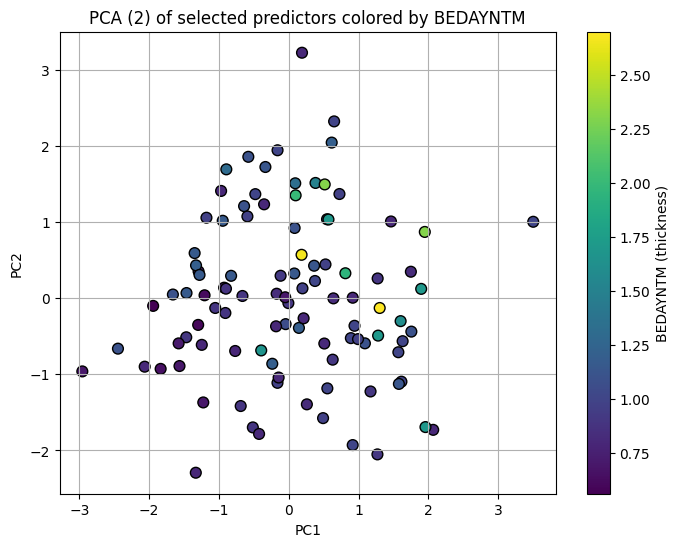


Linear Regression on PCA-2 features:
MSE: 0.1940, MAE: 0.2669, R2: 0.1655

Linear Regression on original standardized features:
MSE: 0.1785, MAE: 0.2425, R2: 0.2321


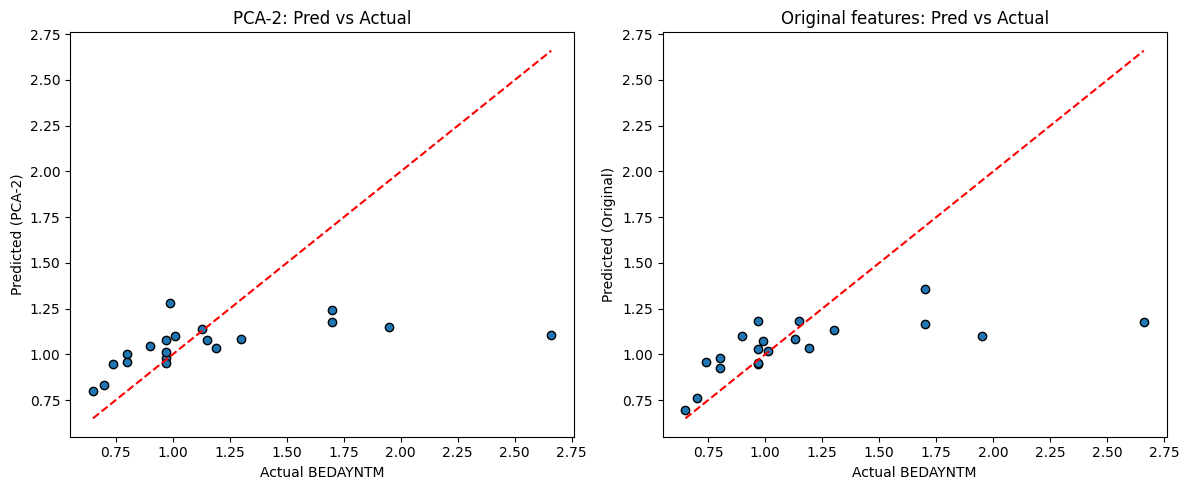


Results saved to variable `linreg_results`.


In [20]:
features = ['TUOI', 'CHOLESTEROL', 'GLUCOSE', 'HA', 'BMI']
for f in features:
    if f not in df_lin.columns:
        raise KeyError(f"Column {f} not found in data")

X = df_lin[features].astype(float).values
y = df_lin['BEDAYNTM'].astype(float).values  # target: độ dày NTM

# Handle any missing values (drop for simplicity)
mask = ~np.isnan(X).any(axis=1)
X = X[mask]
y = y[mask]

# Standardize features
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA to 2 components
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_std)
print('\nPCA 2-components explained variance ratios:', pca2.explained_variance_ratio_)

# Plot PCA 2D scatter colored by target BEDAYNTM
plt.figure(figsize=(8,6))
sc = plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y, cmap='viridis', s=60, edgecolor='k')
plt.colorbar(sc, label='BEDAYNTM (thickness)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (2) of selected predictors colored by BEDAYNTM')
plt.grid(True)
plt.show()

# Use stratified-like split not possible for continuous y; use random split 80/20
indices = np.arange(X.shape[0])
train_idx, test_idx = train_test_split(indices, train_size=0.8, random_state=42)

# Regression on PCA features
X_train_pca = X_pca2[train_idx]
X_test_pca = X_pca2[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)

mse_pca = mean_squared_error(y_test, y_pred_pca)
mae_pca = mean_absolute_error(y_test, y_pred_pca)
r2_pca = r2_score(y_test, y_pred_pca)
print('\nLinear Regression on PCA-2 features:')
print(f'MSE: {mse_pca:.4f}, MAE: {mae_pca:.4f}, R2: {r2_pca:.4f}')

# Regression on original standardized features (same split)
X_train_orig = X_std[train_idx]
X_test_orig = X_std[test_idx]

lr_orig = LinearRegression()
lr_orig.fit(X_train_orig, y_train)
y_pred_orig = lr_orig.predict(X_test_orig)

mse_orig = mean_squared_error(y_test, y_pred_orig)
mae_orig = mean_absolute_error(y_test, y_pred_orig)
r2_orig = r2_score(y_test, y_pred_orig)
print('\nLinear Regression on original standardized features:')
print(f'MSE: {mse_orig:.4f}, MAE: {mae_orig:.4f}, R2: {r2_orig:.4f}')

# Plot predicted vs actual for both
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_pca, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual BEDAYNTM')
plt.ylabel('Predicted (PCA-2)')
plt.title('PCA-2: Pred vs Actual')

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_orig, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual BEDAYNTM')
plt.ylabel('Predicted (Original)')
plt.title('Original features: Pred vs Actual')
plt.tight_layout()
plt.show()

# Save results
linreg_results = {
    'mse_pca': float(mse_pca), 'mae_pca': float(mae_pca), 'r2_pca': float(r2_pca),
    'mse_orig': float(mse_orig), 'mae_orig': float(mae_orig), 'r2_orig': float(r2_orig)
}
print('\nResults saved to variable `linreg_results`.')

# Ví dụ 4 (Bài tập thực hành 3)

## 1. Đọc dữ liệu ảnh, lấy tập dữ liệu 5000 ảnh bất kỳ; giảm số chiều dữ liệu xuống còn 100 chiều (từ 28x28 = 784 chiều ban đầu).

In [21]:
# train path
train_images_path = 'D:/Workspace/HUS/Machine Learning/5. PCA/train-images-idx3-ubyte.gz'
train_labels_path = 'D:/Workspace/HUS/Machine Learning/5. PCA/train-labels-idx1-ubyte.gz'
# test path
test_images_path = 'D:/Workspace/HUS/Machine Learning/5. PCA/t10k-images-idx3-ubyte.gz'
test_labels_path = 'D:/Workspace/HUS/Machine Learning/5. PCA/t10k-labels-idx1-ubyte.gz'

Loaded train images: (60000, 784), test images: (10000, 784)
Sampled X shape: (5000, 784)
PCA -> 100 components; explained variance: 91.71%
X_pca shape: (5000, 100)
PCA -> 100 components; explained variance: 91.71%
X_pca shape: (5000, 100)


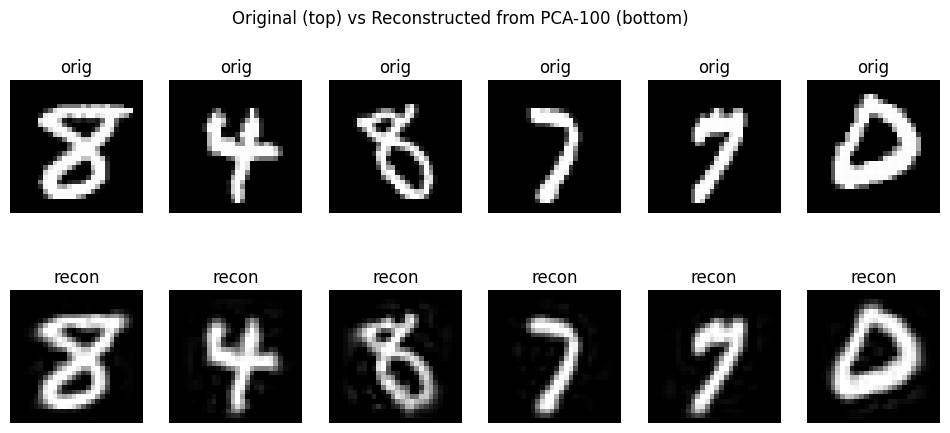

Saved variables: mnist_sample, mnist_pca100


In [33]:
def load_idx_images_gz(path):
    with gzip.open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        buf = f.read(rows * cols * num)
        data = np.frombuffer(buf, dtype=np.uint8).reshape(num, rows*cols)
    return data, rows, cols
def load_idx_labels_gz(path):
    with gzip.open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        buf = f.read(num)
        labels = np.frombuffer(buf, dtype=np.uint8)
    return labels

# load images (fast) - may take a moment
train_imgs, rows, cols = load_idx_images_gz(train_images_path)
test_imgs, _, _ = load_idx_images_gz(test_images_path)
print(f"Loaded train images: {train_imgs.shape}, test images: {test_imgs.shape}")

# concatenate and sample 5000 images reproducibly
all_imgs = np.vstack([train_imgs, test_imgs])
rng = np.random.RandomState(42)
n_sample = 5000
if all_imgs.shape[0] < n_sample:
    raise ValueError(f"Not enough images: {all_imgs.shape[0]} < {n_sample}")
indices = rng.choice(all_imgs.shape[0], size=n_sample, replace=False)
X_sample = all_imgs[indices].astype(np.float32) / 255.0  # normalize to [0,1]
print('Sampled X shape:', X_sample.shape)

# PCA to 100 components
n_components = 100
pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42)
X_pca = pca.fit_transform(X_sample)
explained = np.sum(pca.explained_variance_ratio_)
print(f"PCA -> {n_components} components; explained variance: {explained*100:.2f}%")
print('X_pca shape:', X_pca.shape)

# Reconstruct a few images for visual check
n_display = 6
recon = pca.inverse_transform(X_pca[:n_display])

fig, axes = plt.subplots(2, n_display, figsize=(n_display*2, 5))
for i in range(n_display):
    axes[0, i].imshow(X_sample[i].reshape(rows, cols), cmap='gray')
    axes[0, i].set_title('orig')
    axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(recon[i].reshape(rows, cols), 0, 1), cmap='gray')
    axes[1, i].set_title('recon')
    axes[1, i].axis('off')
plt.suptitle('Original (top) vs Reconstructed from PCA-100 (bottom)')
plt.show()

# Save reduced data for later use in notebook
mnist_sample = X_sample  # (5000, 784)
mnist_pca100 = X_pca     # (5000, 100)
print('Saved variables: mnist_sample, mnist_pca100')

## Áp dụng phương pháp phân loại nhiều lớp Multinomial Logistic Regression (tham khảo bài trước) để phân loại để phân loại tập dữ liệu đã chọn trong ý 1), tỷ lệ train:validation là 0.7:0.3.
Hãy so sánh kết quả (độ chính xác và thời gian) chạy mô hình phân loại trong hai trường hợp:

a) Dữ liệu nguyên bản (giữ nguyên 28x28 = 784 chiều)

b) Dữ liệu đã qua giảm chiều (100 chiều) theo 02 cách: Giảm chiều toàn tập ảnh sau đó chia
train:test – chia train:test rồi mới giảm chiều. So sánh và cho biết cách nào phù hợp hơn.

In [35]:
train_imgs, rows, cols = load_idx_images_gz(train_images_path)
test_imgs, _, _ = load_idx_images_gz(test_images_path)
train_lbls = load_idx_labels_gz(train_labels_path)
test_lbls = load_idx_labels_gz(test_labels_path)
print('Loaded images:', train_imgs.shape, test_imgs.shape)
all_imgs = np.vstack([train_imgs, test_imgs])
all_lbls = np.hstack([train_lbls, test_lbls])
rng = np.random.RandomState(42)
n_sample = 5000
if all_imgs.shape[0] < n_sample:
    raise ValueError(f'Not enough images: {all_imgs.shape[0]} < {n_sample}')
indices = rng.choice(all_imgs.shape[0], size=n_sample, replace=False)
X = all_imgs[indices].astype(np.float32) / 255.0
y = all_lbls[indices].astype(int)
print('Sampled shapes', X.shape, y.shape)

def run_logreg(X_in, y_in, solver='saga'):
    # stratified split
    X_tr, X_val, y_tr, y_val = train_test_split(X_in, y_in, train_size=0.7, stratify=y_in, random_state=42)
    clf = LogisticRegression(multi_class='multinomial', solver=solver, max_iter=1000, n_jobs=-1, random_state=42)
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    t_train = time.time() - t0
    t0 = time.time()
    y_pred = clf.predict(X_val)
    t_pred = time.time() - t0
    acc = accuracy_score(y_val, y_pred)
    return {'acc':acc, 'train_time':t_train, 'pred_time':t_pred, 'clf':clf}

results = {}

Loaded images: (60000, 784) (10000, 784)
Sampled shapes (5000, 784) (5000,)


### a. Dữ liệu nguyên bản

In [43]:
# Case A: Original features (784)
print('\nCase A: Original features (784 dims) -- training logistic regression')
res_orig = run_logreg(X, y, solver='saga')
results['original'] = res_orig
print(f"Original -> acc: {res_orig['acc']:.4f}, train_time: {res_orig['train_time']:.3f}s, pred_time: {res_orig['pred_time']:.3f}s")



Case A: Original features (784 dims) -- training logistic regression
Original -> acc: 0.8907, train_time: 34.609s, pred_time: 0.001s
Original -> acc: 0.8907, train_time: 34.609s, pred_time: 0.001s


### b1. Giảm chiều toàn tập ảnh sau đó chia train:test 

In [ ]:
print('\nCase B1: PCA on FULL then split (fit PCA on all sampled data)')
n_comp = 100
pca_full = PCA(n_components=n_comp, svd_solver='randomized', random_state=42)
X_pca_full = pca_full.fit_transform(X)
print('Explained variance (100 comps):', np.sum(pca_full.explained_variance_ratio_))
res_b1 = run_logreg(X_pca_full, y, solver='saga')
results['pca_full_then_split'] = res_b1
print(f"PCA-full -> acc: {res_b1['acc']:.4f}, train_time: {res_b1['train_time']:.3f}s, pred_time: {res_b1['pred_time']:.3f}s")


Case B1: PCA on FULL then split (fit PCA on all sampled data)
Explained variance (100 comps): 0.91712457
Explained variance (100 comps): 0.91712457
PCA-full -> acc: 0.8907, train_time: 5.159s, pred_time: 0.001s
PCA-full -> acc: 0.8907, train_time: 5.159s, pred_time: 0.001s


### b2. – Chia train:test rồi mới giảm chiều

In [42]:
print('\nCase B2: Split then PCA')
# split first
X_tr0, X_val0, y_tr0, y_val0 = train_test_split(X, y, train_size=0.7, stratify=y, random_state=42)
pca_train = PCA(n_components=n_comp, svd_solver='randomized', random_state=42)
X_tr_pca = pca_train.fit_transform(X_tr0)
X_val_pca = pca_train.transform(X_val0)
print('Explained variance (train-fit):', np.sum(pca_train.explained_variance_ratio_))
# train classifier
clf = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, n_jobs=-1, random_state=42)
t0 = time.time()
clf.fit(X_tr_pca, y_tr0)
t_train = time.time() - t0
t0 = time.time()
y_pred = clf.predict(X_val_pca)
t_pred = time.time() - t0
acc = accuracy_score(y_val0, y_pred)
results['split_then_pca'] = {'acc':acc, 'train_time':t_train, 'pred_time':t_pred, 'clf':clf}
print(f"Split-then-PCA -> acc: {acc:.4f}, train_time: {t_train:.3f}s, pred_time: {t_pred:.3f}s")


Case B2: Split then PCA
Explained variance (train-fit): 0.9184226
Split-then-PCA -> acc: 0.8913, train_time: 4.757s, pred_time: 0.001s
Split-then-PCA -> acc: 0.8913, train_time: 4.757s, pred_time: 0.001s


## Kết luận

In [41]:
# Summary table
print('\nSummary results (train 0.7 / val 0.3):')
print('{:30s} {:>8s} {:>14s} {:>12s}'.format('variant','acc','train_time(s)','pred_time(s)'))
for k,v in results.items():
    print('{:30s} {:8.4f} {:14.3f} {:12.3f}'.format(k, v['acc'], v['train_time'], v['pred_time']))


Summary results (train 0.7 / val 0.3):
variant                             acc  train_time(s) pred_time(s)
original                         0.8907         37.142        0.002
pca_full_then_split              0.8907          5.159        0.001
split_then_pca                   0.8913          5.912        0.001
